Análisis Exploratorio de Datos (EDA) - Dataset Bruto
Objetivo: Diagnosticar la calidad del dato extraído mediante Web Scraping antes de aplicar cualquier transformación o limpieza. 
Se evaluarán distribuciones, valores atípicos (outliers), presencia de nulos y coherencia física de los registros inmobiliarios.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética para gráficos de nivel académico
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

# Carga de datos (con manejo de delimitador por si acaso)
try:
    df_bruto = pd.read_csv('dataset_unificado_bruto.csv', sep=',')
except:
    df_bruto = pd.read_csv('dataset_unificado_bruto.csv', sep=';')

print(f"Dimensiones del dataset bruto: {df_bruto.shape[0]} filas y {df_bruto.shape[1]} columnas.")
display(df_bruto.head(3))

C:\Users\DANI\AppData\Local\Temp\ipykernel_14456\3536972189.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Dimensiones del dataset bruto: 1995 filas y 22 columnas.


,Enlace,Precio,Superficie_Construida,Superficie_Util,Habitaciones,Banos,Planta,Antiguedad,Referencia,Descripcion,...,Trastero,Terraza,Balcon,Jardin,Piscina,Aire_Acondicionado,Estado,Exterior,Gastos_Comunidad,Origen
0,https://www.pisos.com/comprar/piso-russafa4600...,840000.0,140.0,128.0,3.0,2.0,2.0,Más de 50 años,13931/5458,Grupo Alain inmobiliaria vende este exclusivo ...,...,No,No,No,No,No,Sí,NaN,NaN,NaN,Pisos.com
1,https://www.pisos.com/comprar/piso-el_carme460...,319000.0,64.0,60.0,NaN,NaN,2.0,Más de 50 años,13913/5458,Grupo Alain inmobiliaria vende piso en la zona...,...,No,No,Sí,No,No,Sí,NaN,NaN,NaN,Pisos.com
2,https://www.pisos.com/comprar/piso-eixample_gr...,620000.0,108.0,100.0,4.0,2.0,5.0,NaN,14189/5458,Grupo Alain Inmobiliaria vede un impresionante...,...,No,No,Sí,No,No,Sí,NaN,NaN,NaN,Pisos.com


## Auditoría de Valores Nulos (Missing Values)
Analizamos qué porcentaje de información falta en cada columna para decidir, en la futura fase de limpieza, si imputar esos datos o eliminar la columna por completo (Navaja de Ockham).

C:\Users\DANI\AppData\Local\Temp\ipykernel_14456\243912763.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nulos_pct.values, y=nulos_pct.index, palette="Reds_r")


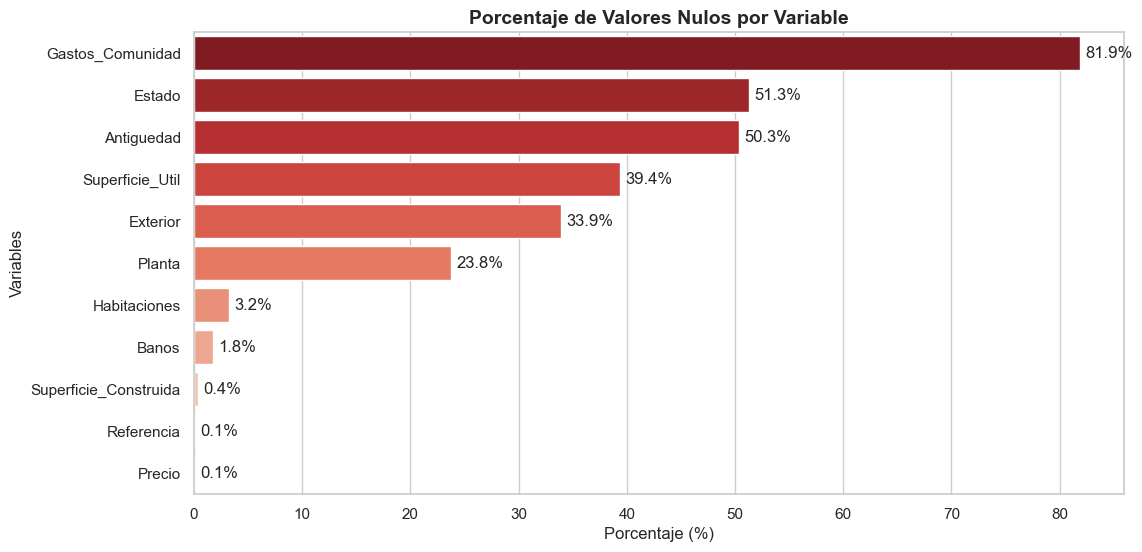

In [2]:
# Cálculo del porcentaje de nulos
nulos_pct = (df_bruto.isnull().sum() / len(df_bruto)) * 100
nulos_pct = nulos_pct[nulos_pct > 0].sort_values(ascending=False)

# Visualización
plt.figure(figsize=(12, 6))
sns.barplot(x=nulos_pct.values, y=nulos_pct.index, palette="Reds_r")
plt.title('Porcentaje de Valores Nulos por Variable', fontsize=14, fontweight='bold')
plt.xlabel('Porcentaje (%)')
plt.ylabel('Variables')

# Añadir etiquetas de datos
for i, v in enumerate(nulos_pct.values):
    plt.text(v + 0.5, i, f"{v:.1f}%", va='center')

plt.show()

**Conclusión del Diagnóstico de Nulos:**
Observamos que variables como `Gastos_Comunidad` (>80% de nulos) y `Antiguedad` (>50%) son funcionalmente inútiles en su estado actual. Su alta vacuidad se debe a la omisión sistemática por parte del anunciante. Retener estas columnas e intentar imputarlas con medias estadísticas introduciría un sesgo inaceptable en el modelo. Serán candidatas a eliminación estructural.

## 2. Distribución de Variables Continuas: Precio y Superficie
El objetivo es detectar la presencia de sesgos de mercado y valores atípicos (outliers) que representen anomalías físicas o comerciales (nuda propiedad, garajes, edificios enteros).

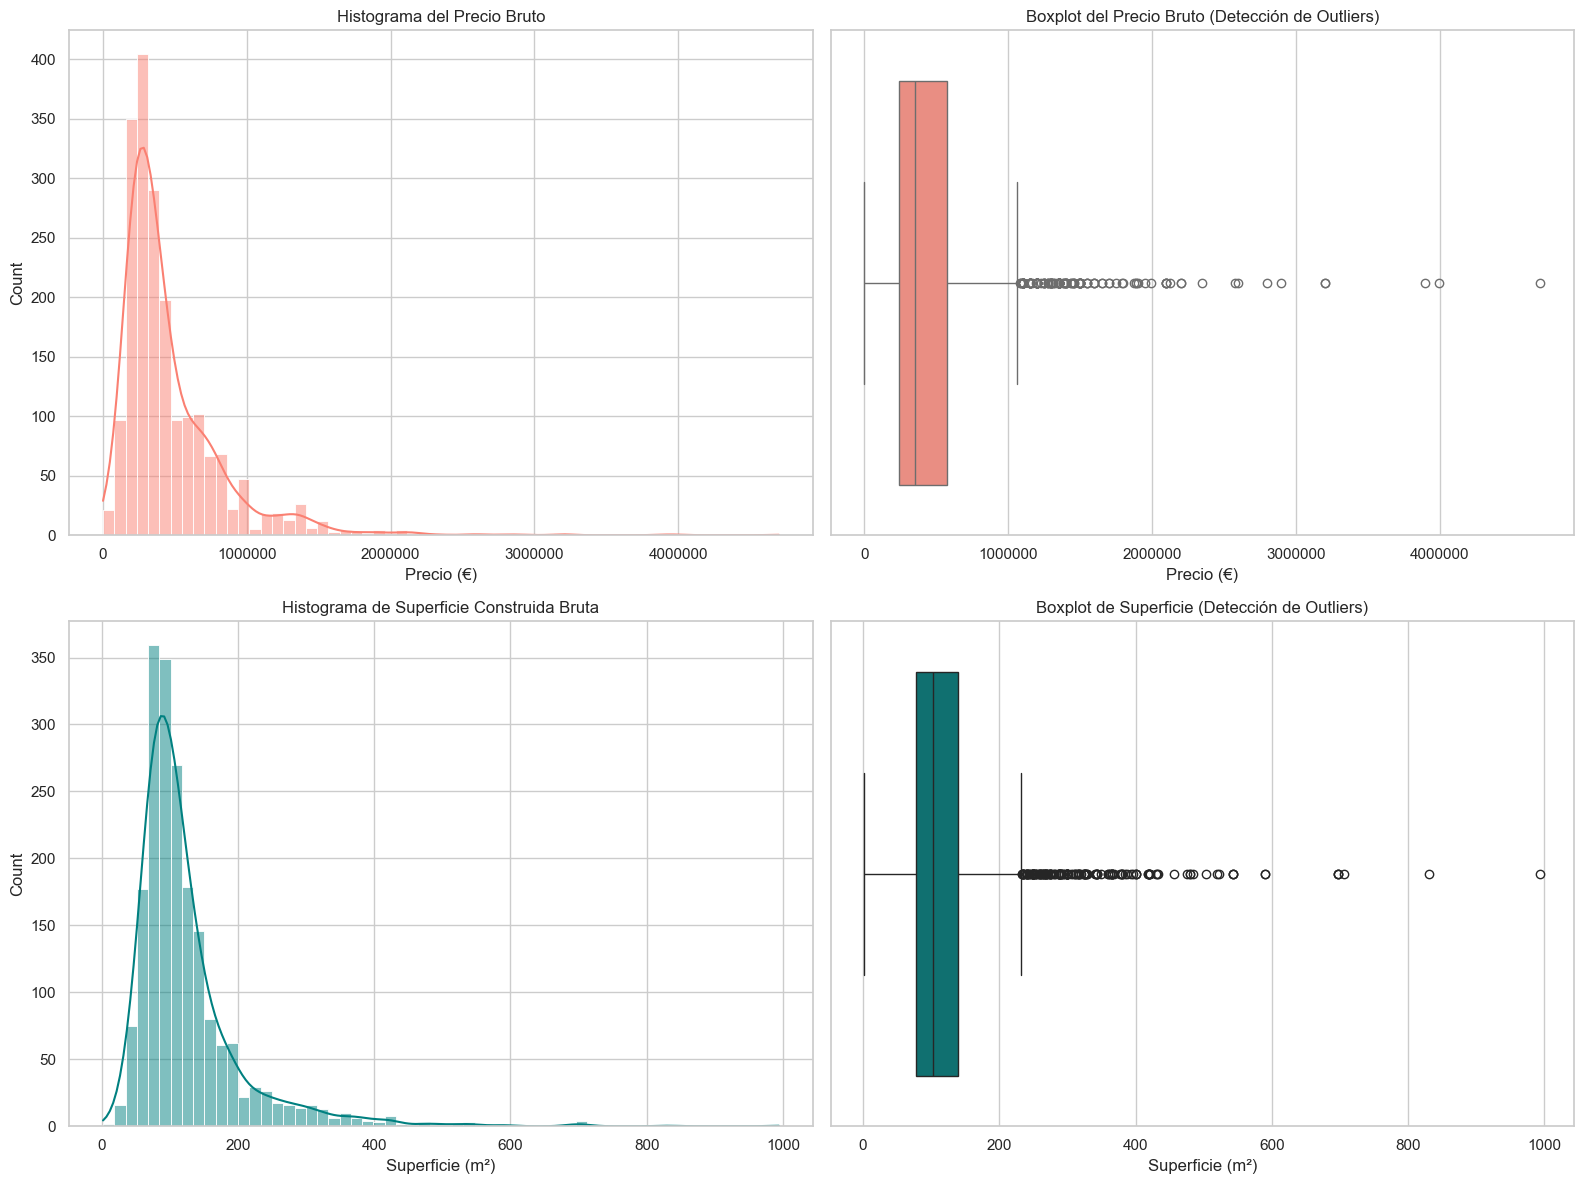

Estadísticos descriptivos del Precio:


count       1994.0
mean      466076.0
std       383133.0
min           25.0
25%       240000.0
50%       350000.0
75%       573750.0
max      4700000.0
Name: Precio, dtype: float64


Estadísticos descriptivos de la Superficie:


count    1987.0
mean      125.0
std        82.0
min         2.0
25%        78.0
50%       103.0
75%       140.0
max       994.0
Name: Superficie_Construida, dtype: float64

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- PRECIO ---
# Histograma
sns.histplot(df_bruto['Precio'], bins=60, kde=True, ax=axes[0, 0], color="salmon")
axes[0, 0].set_title('Histograma del Precio Bruto')
axes[0, 0].set_xlabel('Precio (€)')
axes[0, 0].ticklabel_format(style='plain', axis='x')

# Boxplot
sns.boxplot(x=df_bruto['Precio'], ax=axes[0, 1], color="salmon")
axes[0, 1].set_title('Boxplot del Precio Bruto (Detección de Outliers)')
axes[0, 1].set_xlabel('Precio (€)')
axes[0, 1].ticklabel_format(style='plain', axis='x')

# --- SUPERFICIE ---
# Histograma
sns.histplot(df_bruto['Superficie_Construida'], bins=60, kde=True, ax=axes[1, 0], color="teal")
axes[1, 0].set_title('Histograma de Superficie Construida Bruta')
axes[1, 0].set_xlabel('Superficie (m²)')

# Boxplot
sns.boxplot(x=df_bruto['Superficie_Construida'], ax=axes[1, 1], color="teal")
axes[1, 1].set_title('Boxplot de Superficie (Detección de Outliers)')
axes[1, 1].set_xlabel('Superficie (m²)')

plt.tight_layout()
plt.show()

print("Estadísticos descriptivos del Precio:")
display(df_bruto['Precio'].describe().round(0))
print("\nEstadísticos descriptivos de la Superficie:")
display(df_bruto['Superficie_Construida'].describe().round(0))

**Conclusiones de Distribución (Anomalías detectadas):**
1. **El sesgo del Precio:** Existe una larga "cola" hacia la derecha (inmuebles de lujo). Sin embargo, el problema radica en el límite inferior: el boxplot y los estadísticos indican precios mínimos irracionales (ej. pisos de < 60.000€ en Valencia capital), lo que alerta sobre activos no habitables u ocupados. Se requiere un umbral mínimo (suelo) en la limpieza.
2. **Caos en la Superficie:** El boxplot de la superficie es prácticamente ilegible debido a los "mega-outliers" (valores por encima de los 1.000 m²). Esto confirma la ingesta errónea de fincas completas o masías agrarias. Por abajo, valores cercanos a 0 m² indican la presencia de trasteros camuflados. Justifica la futura aplicación del método IQR.

## 4. Análisis Semántico: La trampa de las variables booleanas y categóricas
Evaluamos cómo se distribuyen las etiquetas comerciales ("Estado" y "Jardín") para justificar la necesidad de un motor de NLP.

C:\Users\DANI\AppData\Local\Temp\ipykernel_14456\2553112797.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=estado_counts.index, x=estado_counts.values, palette="magma", ax=axes[1])


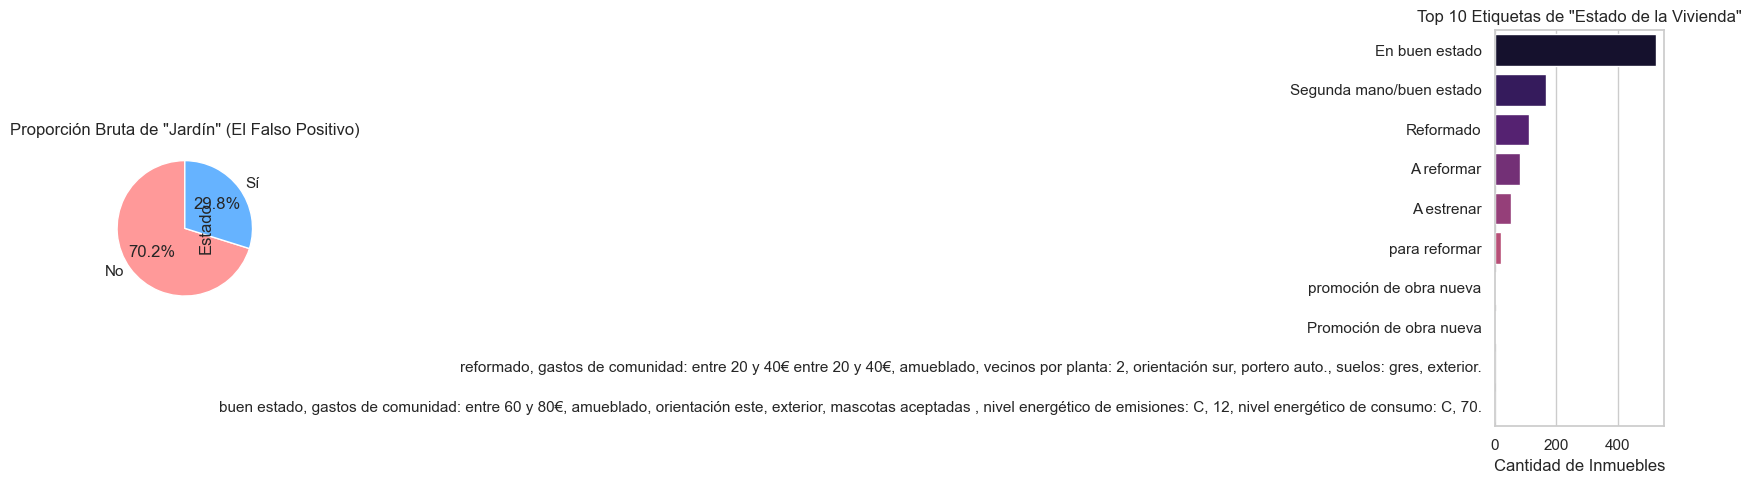

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# El problema del Jardín
jardin_counts = df_bruto['Jardin'].value_counts()
axes[0].pie(jardin_counts, labels=jardin_counts.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], startangle=90)
axes[0].set_title('Proporción Bruta de "Jardín" (El Falso Positivo)')

# La fragmentación del Estado
estado_counts = df_bruto['Estado'].value_counts().head(10) # Mostramos solo los 10 primeros por legibilidad
sns.barplot(y=estado_counts.index, x=estado_counts.values, palette="magma", ax=axes[1])
axes[1].set_title('Top 10 Etiquetas de "Estado de la Vivienda"')
axes[1].set_xlabel('Cantidad de Inmuebles')

plt.tight_layout()
plt.show()

**Conclusiones Semánticas:**
1. **El Mito del Jardín:** El gráfico circular muestra que un porcentaje altísimo e irreal de la oferta afirma tener jardín. Esto evidencia que el algoritmo de *scraping* ha capturado la palabra "jardín" de frases como "junto a los jardines del Turia". Se hace obligatorio un cruce de validación con la tipología de la vivienda.
2. **Alta Cardinalidad:** El gráfico de barras del estado de la vivienda muestra múltiples formas de decir lo mismo (ej. "En buen estado", "Para entrar a vivir"). Entrenar un modelo con esta fragmentación reduciría drásticamente su precisión. Se requerirá normalización semántica.

**Veredicto Final del EDA:** El dataset contiene el valor subyacente del mercado, pero está envuelto en una densa capa de ruido técnico y comercial. Los descubrimientos de este cuaderno justifican matemáticamente cada uno de los pasos que se aplicarán en el pipeline de `01_Limpieza_NLP`.